# Q1: Setup & Exploration

**Phase 1-2:** Project Setup, Data Exploration  
**Points: 6 points**

**Focus:** Load data, perform initial inspection, identify data quality issues.

**Lecture Reference:** Lecture 11, Notebook 1 ([`11/demo/01_setup_exploration_cleaning.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/01_setup_exploration_cleaning.ipynb)), Phases 1-2. Also see Lecture 04 (pandas I/O) and Lecture 07 (visualization).

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

# Create output directory
os.makedirs('output', exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported and output directory created.")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Libraries imported and output directory created.
pandas version: 2.3.3
numpy version: 2.3.5


---

## Objective

Load the Chicago Beach Weather Sensors dataset, perform initial inspection, and identify data quality issues.

**Note:** The datetime column in this dataset is named `Measurement Timestamp`.

**Time Series Note:** Unlike the lecture's NYC Taxi data (event-based), this dataset is **time-series data** with continuous sensor readings. The data is already indexed by time, so you'll work with datetime-indexed dataframes throughout. See **Lecture 09** for time series operations. For time series visualizations, you may want to use pandas `resample()` to aggregate data (e.g., daily averages) for clearer visualization of long-term trends.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q1_data_info.txt`
**Format:** Plain text file
**Content:** Dataset information including:
- Dataset shape (rows × columns)
- Column names (one per line or comma-separated)
- Data types for each column
- Date range (start date and end date) - **REQUIRED if temporal data**
- Missing value counts for each column (column name: count)

**Example format:**
```
Dataset Shape: 50000 rows × 10 columns

Column Names:
- Measurement Timestamp
- Beach
- Water Temperature
- Air Temperature
...

Data Types:
- Measurement Timestamp: datetime64[ns]
- Beach: object
- Water Temperature: float64
...

Date Range:
Start: 2022-01-01 00:00:00
End: 2027-09-15 07:00:00

Missing Values:
- Water Temperature: 2500 (5.0%)
- Air Temperature: 1500 (3.0%)
...
```

### 2. `output/q1_exploration.csv`
**Format:** CSV file
**Required Columns (exact names):** `column_name`, `mean`, `std`, `min`, `max`, `missing_count`
**Content:** One row per numeric column in the dataset
- `column_name`: Name of the numeric column
- `mean`: Mean value (float)
- `std`: Standard deviation (float)
- `min`: Minimum value (float)
- `max`: Maximum value (float)
- `missing_count`: Number of missing values (integer)

**Example:**
```csv
column_name,mean,std,min,max,missing_count
Water Temperature,15.23,5.12,0.5,28.7,2500
Air Temperature,18.45,8.23,-5.2,35.8,1500
Wind Speed,6.78,4.56,0.1,25.3,0
```

### 3. `output/q1_visualizations.png`
**Format:** PNG image file
**Content:** At least 2 plots in a single figure (use subplots)
**Required plots:**
1. **Distribution plot:** Histogram or density plot of at least one numeric variable
2. **Time series plot:** Line plot showing a numeric variable over time (if temporal data)

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

---

## Requirements Checklist

- [ ] Data loaded successfully from `data/beach_sensors.csv`
- [ ] Initial inspection completed (shape, info, head, describe)
- [ ] Missing values identified and counted
- [ ] Basic visualizations created (at least 2 plots: distribution + time series)
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Load and inspect the dataset** - Use standard pandas I/O and inspection methods
2. **Parse datetime** - Identify and convert datetime column(s)
3. **Identify missing values** - Count and calculate percentages per column
4. **Create visualizations** - Distribution plot + time series plot (use subplots)
5. **Save artifacts** - Write to the three required output files

---

## Decision Points

- **Visualization choices:** What types of plots best show your data? See Lecture 11 Notebook 1 for examples.
- **Data quality assessment:** What issues do you see? Missing data patterns? Outliers? Inconsistent formats? Document these for Q2.

---

## Checkpoint

After Q1, you should have:
- [ ] Data loaded successfully
- [ ] Basic statistics calculated
- [ ] Initial visualizations created (2+ plots)
- [ ] Data quality issues identified
- [ ] All 3 artifacts saved: `q1_data_info.txt`, `q1_exploration.csv`, `q1_visualizations.png`

---

**Next:** Continue to `q2_data_cleaning.md` for Data Cleaning.


In [2]:
# 1. output/q1_dat-info.txt

## Make output directory
os.makedirs('output', exist_ok=True)

## Load dataset
beach = pd.read_csv('data/beach_sensors.csv')
print(f"Beach sensors dataset loaded with shape: {beach.shape[0]} rows x {beach.shape[1]} columns\n")

## Convert 'Measurement Timestamp' to datetime
beach['Measurement Timestamp'] = pd.to_datetime(beach['Measurement Timestamp'])
print("Converted 'Measurement Timestamp' to datetime format.\n")

## Dataset shape Dataframe
info = []

info.append("=" * 60)
info.append("Chicago Beach Weather Sensors - Dataset Information")
info.append("=" * 60)
info.append("")
info.append(f"Dataset Shape: {beach.shape[0]} rows x {beach.shape[1]} columns")
info.append("")

## Data Types
info.append("-" * 60)
info.append("Column Names:")
info.append("-" * 60)
for col in beach.columns:
    info.append(f" -{col}")
info.append("")

## Data Types and Non-Null Counts
info.append("-" * 60)
info.append("Data Types and Non-Null Counts:")
info.append("-" * 60)
for col, dtype in beach.dtypes.items():
    info.append(f" {col}: {dtype}, Non-Null Count: {beach[col].notnull().sum()}")
info.append("")

## Date Range (start and end dates)
info.append("-" * 60)
info.append("Date Range:")
info.append("-" * 60)
start_date = beach['Measurement Timestamp'].min()
end_date = beach['Measurement Timestamp'].max()
info.append(f" Start Date: {start_date}")
info.append(f" End Date: {end_date}")
info.append(f"Time Span: {(end_date - start_date).days} days")
info.append("")

## Missing Value Counts
info.append("-" * 60)
info.append("Missing Value Counts per Column:")
info.append("-" * 60)
missing_counts = beach.isnull().sum()
for col, count in missing_counts.items():
    info.append(f" {col}: {count} missing values")
info.append("")

## Total Missing Values
total_missing = missing_counts.sum()
total_cells = beach.shape[0] * beach.shape[1]
missing_percentage = (total_missing / total_cells) * 100
info.append(f"Total Missing Values: {total_missing} out of {total_cells} cells ({missing_percentage:.2f}%)")
info.append("=" * 60)

## Write to file
with open('output/q1_dat-info.txt', 'w') as f:
    f.write("\n".join(info))

print(f"Dataset information written to 'output/q1_dat-info.txt'.")


Beach sensors dataset loaded with shape: 196056 rows x 18 columns

Converted 'Measurement Timestamp' to datetime format.

Dataset information written to 'output/q1_dat-info.txt'.


In [3]:
# 2. output/q1_exploration.csv

# Load Dataset
beach = pd.read_csv('data/beach_sensors.csv')
print(f"Beach sensors dataset loaded with shape: {beach.shape[0]} rows x {beach.shape[1]} columns\n")

# Numeric Columns
numeric_cols = beach.select_dtypes(include=['number']).columns.tolist()
print(f"Found {len(numeric_cols)} numeric columns for exploration.\n")
for col in numeric_cols:
    print(f"    - {col}")
print()

# Create Exploration DataFrame with means, std dev, min, max, missing counts
exploration = []

for col in numeric_cols:
    row = {
        'column_name': col,
        'mean': beach[col].mean(),
        'std_dev': beach[col].std(),
        'min': beach[col].min(),
        'max': beach[col].max(),
        'missing_count': beach[col].isnull().sum()
    }
    exploration.append(row)

# Create DataFrame with results
exploration_df = pd.DataFrame(exploration)
exploration_df = exploration_df[['column_name', 'mean', 'std_dev', 'min', 'max', 'missing_count']]

# Save to CSV
exploration_df.to_csv('output/q1_exploration.csv', index=False)
print(f"Exploration statistics written to 'output/q1_exploration.csv'.")
print(exploration_df.to_string(index=False))
print()
print(f"\nTotal numeric columns analyzed: {len(exploration_df)}")


Beach sensors dataset loaded with shape: 196056 rows x 18 columns

Found 14 numeric columns for exploration.

    - Air Temperature
    - Wet Bulb Temperature
    - Humidity
    - Rain Intensity
    - Interval Rain
    - Total Rain
    - Precipitation Type
    - Wind Direction
    - Wind Speed
    - Maximum Wind Speed
    - Barometric Pressure
    - Solar Radiation
    - Heading
    - Battery Life

Exploration statistics written to 'output/q1_exploration.csv'.
         column_name       mean    std_dev        min     max  missing_count
     Air Temperature  12.643593  10.428347     -29.78   37.60             75
Wet Bulb Temperature  10.289050   9.398698     -28.90   28.40          75818
            Humidity  68.019438  15.636975       0.00  100.00              0
      Rain Intensity   0.158981   1.794944       0.00  183.60          75818
       Interval Rain   0.142465   1.097608      -0.90   63.42              0
          Total Rain 141.579176 190.538218       0.00 1056.10          75

### 3. `output/q1_visualizations.png`
**Format:** PNG image file
**Content:** At least 2 plots in a single figure (use subplots)
**Required plots:**
1. **Distribution plot:** Histogram or density plot of at least one numeric variable
2. **Time series plot:** Line plot showing a numeric variable over time (if temporal data)

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

Data Loaded with shape: 196056 rows x 18 columns

Converted 'Measurement Timestamp' to datetime format.

Numeric columns available: ['Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'Battery Life']

Numeric columns with data: ['Air Temperature', 'Wet Bulb Temperature', 'Humidity', 'Rain Intensity', 'Interval Rain', 'Total Rain', 'Precipitation Type', 'Wind Direction', 'Wind Speed', 'Maximum Wind Speed', 'Barometric Pressure', 'Solar Radiation', 'Heading', 'Battery Life']
Number of valid columns: 14

Created 4 plots for Air Temperature and Wet Bulb Temperature.

Visualizations saved to 'output/q1_visualizations.png'.


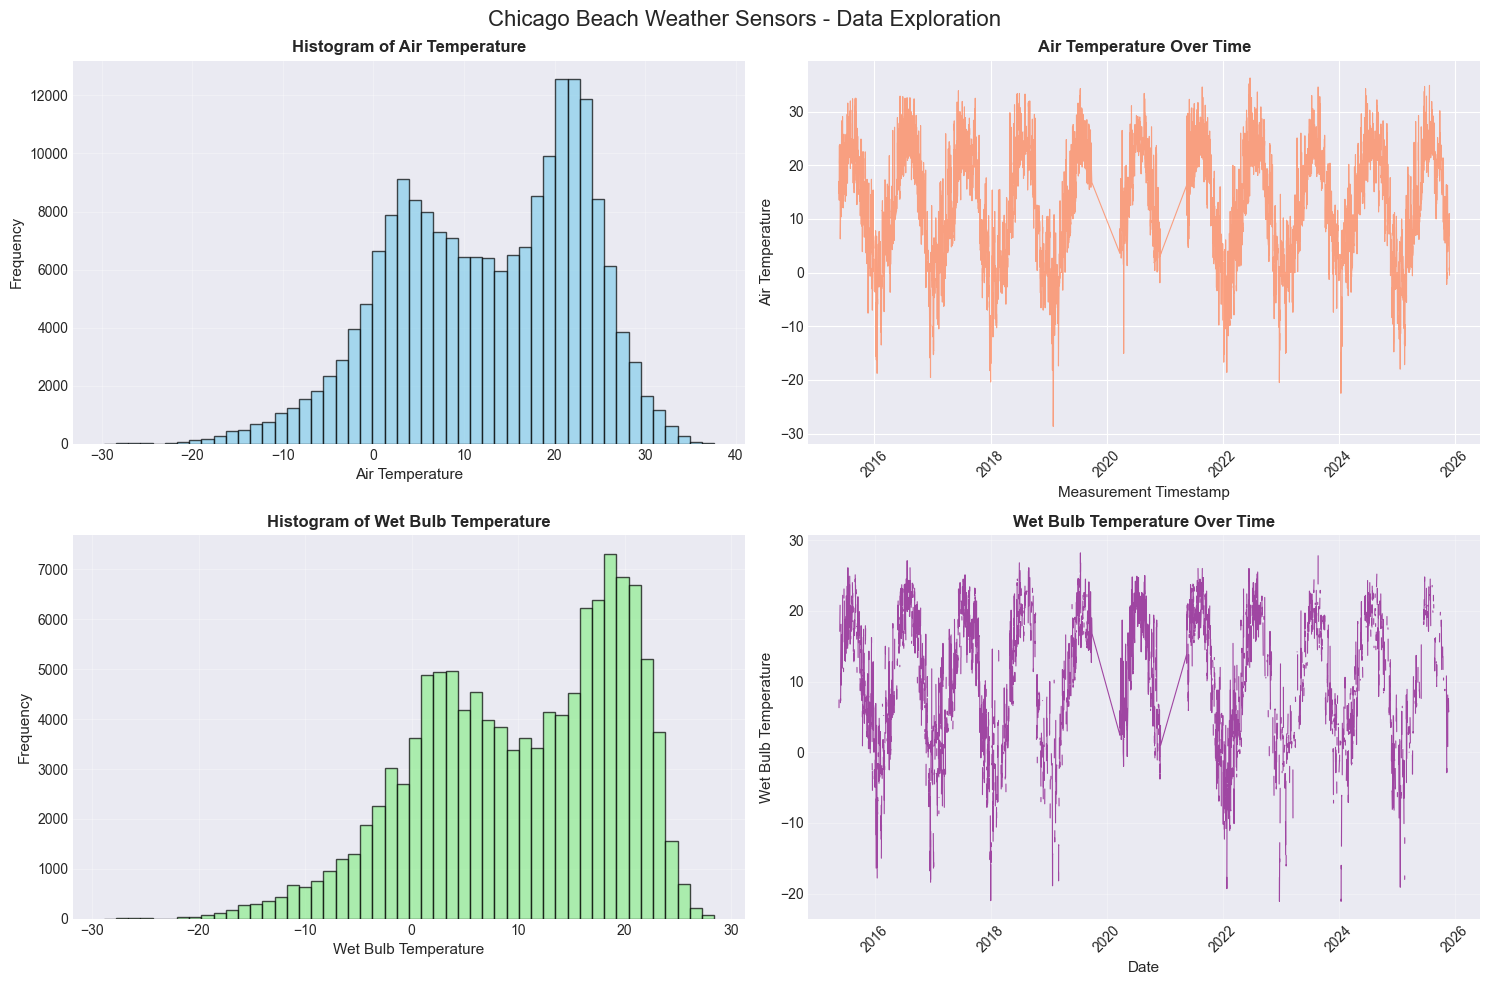

In [4]:
# 3. output/q1_visualizations.png

# Load Dataset
beach = pd.read_csv('data/beach_sensors.csv')
print(f"Data Loaded with shape: {beach.shape[0]} rows x {beach.shape[1]} columns\n")

# Convert 'Measurement Timestamp' to datetime
beach['Measurement Timestamp'] = pd.to_datetime(beach['Measurement Timestamp'])
print("Converted 'Measurement Timestamp' to datetime format.\n")

# Sort by timestamp for time series plotting
beach = beach.sort_values('Measurement Timestamp')

# Numeric Columns
numeric_cols = beach.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns available: {numeric_cols}\n")

# Filter to only columns wwith at least some non-null values
valid_cols = [col for col in numeric_cols if beach[col].notna().sum() > 0]
print(f"Numeric columns with data: {valid_cols}")
print(f"Number of valid columns: {len(valid_cols)}\n")

# Figure with 2x2 subplots
if len(valid_cols) >=2:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Chicago Beach Weather Sensors - Data Exploration', fontsize=16)

# Plot Distribution (Histogram)
    plot_col1 = valid_cols[0]
    plot_col2 = valid_cols[1]

# Sample data for plotting if too large
    if len(beach) > 10000:
        beach_sample = beach.sample(n=10000, random_state=42).sort_values('Measurement Timestamp')
    else:
        beach_sample = beach

# Plot1: Distribution of first numeric variable
    axes[0, 0].hist(beach[plot_col1].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0,0].set_xlabel(plot_col1, fontsize=11)
    axes[0,0].set_ylabel('Frequency', fontsize=11)
    axes[0,0].set_title(f'Histogram of {plot_col1}', fontsize=12, fontweight='bold')
    axes[0,0].grid(True, alpha=0.3)

# Plot2: Time Series
    axes[0,1].plot(beach_sample['Measurement Timestamp'], beach_sample[plot_col1], color='coral', alpha=0.7, linewidth=0.8)
    axes[0,1].set_xlabel('Measurement Timestamp', fontsize=11)
    axes[0,1].set_ylabel(plot_col1, fontsize=11)
    axes[0,1].set_title(f'{plot_col1} Over Time', fontsize=12, fontweight='bold')
    axes[0,1].tick_params(axis='x', rotation=45)

# Plot3: Distribution of second numeric variable
    axes[1,0].hist(beach[plot_col2].dropna(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1,0].set_xlabel(plot_col2, fontsize=11)
    axes[1,0].set_ylabel('Frequency', fontsize=11)
    axes[1,0].set_title(f'Histogram of {plot_col2}', fontsize=12, fontweight='bold')
    axes[1,0].grid(True, alpha=0.3)

# Plot4: Time Series of second variable
    axes[1,1].plot(beach_sample['Measurement Timestamp'], beach_sample[plot_col2], color='purple', alpha=0.7, linewidth=0.8)
    axes[1,1].set_xlabel('Date', fontsize=11)
    axes[1,1].set_ylabel(plot_col2, fontsize=11)
    axes[1,1].set_title(f'{plot_col2} Over Time', fontsize=12, fontweight='bold')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].tick_params(axis='x', rotation=45)

    print(f"Created 4 plots for {plot_col1} and {plot_col2}.\n")

elif len(valid_cols) == 1:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Chicago Beach Weather Sensors - Data Exploration', fontsize=16,fontweight='bold')

    plot_col1 = valid_cols[0]

# Adjust layout to prevent overlap
plt.tight_layout()

# Save figure
plt.savefig('output/q1_visualizations.png', dpi=150, bbox_inches='tight')
print(f"Visualizations saved to 'output/q1_visualizations.png'.")

# Show Plot
plt.show()